 

---

## Introduction

This project focuses on **end-to-end preprocessing, feature analysis, and model comparison** for a binary classification task using the popular *Pima Indians Diabetes Dataset*. The workflow includes:

- **Data cleaning**: Handling outliers with Isolation Forest, replacing invalid zero values, imputing missing data via KNN, and scaling features.  
- **Exploratory analysis**: Visualizing distributions, correlations, PCA projections, and feature importance rankings.  
- **Model experimentation**: Comparing classic machine learning models (Random Forest, XGBoost, Gradient Boosting) via GridSearchCV, alongside deep learning (ANN) and SVM for performance benchmarking.  
- **Final model selection**: Determining the most accurate approach for this dataset.

The emphasis is not only on raw accuracy but also **on clean and explainable data preprocessing**, ensuring that performance comparisons are fair and reproducible.

> **Important Note:**  
> While **Gradient Boosting** can sometimes perform exceptionally well—even on datasets with a relatively small number of samples—this is **not always guaranteed**. Its success depends on factors such as data quality, feature relevance, noise level, and hyperparameter tuning. Always validate and compare results with other models before drawing conclusions.

---


In [121]:
# ================================
# Import libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

In [122]:
# ================================
# 📂 Load dataset
# ================================
df = pd.read_csv(r".\diabetes.csv")

print("🔍 First rows of data:")
print(df.head())

print("\n📊 Dataset info:")
print(df.info())

print(f"\nDataset shape: {df.shape}")
print(f"Duplicated rows: {df.duplicated().sum()}")

🔍 First rows of data:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

📊 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int

In [123]:
# ================================
# 🚨 Detect Outliers (Isolation Forest)
# ================================
iso = IsolationForest(contamination=0.1, random_state=42)
df["outlier"] = iso.fit_predict(df.drop(columns="Outcome"))

# Summary
df_outliers = df[df["outlier"] == -1]
df_normals = df[df["outlier"] == 1]

print("\n📈 Descriptive statistics for outliers:")
print(df_outliers.describe())

outlier_percentage = (len(df_outliers) / len(df)) * 100
print(f"\nNumber of outliers: {len(df_outliers)}")
print(f"Total samples: {len(df)}")
print(f"Percentage of outliers: {outlier_percentage:.2f}%")




📈 Descriptive statistics for outliers:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count    77.000000   77.000000      77.000000      77.000000   77.000000   
mean      4.493506  142.363636      55.740260      22.000000  171.506494   
std       4.238369   42.650017      38.055846      21.580937  224.622820   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       0.000000  118.000000       0.000000       0.000000    0.000000   
50%       4.000000  145.000000      70.000000      24.000000    0.000000   
75%       8.000000  177.000000      82.000000      37.000000  300.000000   
max      17.000000  199.000000     114.000000      99.000000  846.000000   

             BMI  DiabetesPedigreeFunction        Age   Outcome  outlier  
count  77.000000                 77.000000  77.000000  77.00000     77.0  
mean   32.379221                  0.710753  41.038961   0.61039     -1.0  
std    15.346827                  0.558185  15.436

In [124]:
df["outlier"]

0      1
1      1
2      1
3      1
4     -1
      ..
763   -1
764    1
765    1
766    1
767    1
Name: outlier, Length: 768, dtype: int64

C:\Users\p-fr\AppData\Local\Temp\ipykernel_11248\324640483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="outlier", data=df, palette=['red', 'green'])


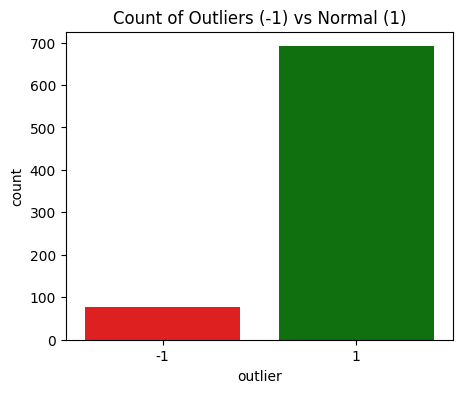

In [125]:
# Plot Outlier Count

plt.figure(figsize=(5, 4))
sns.countplot(x="outlier", data=df, palette=['red', 'green'])
plt.title("Count of Outliers (-1) vs Normal (1)")
plt.show()

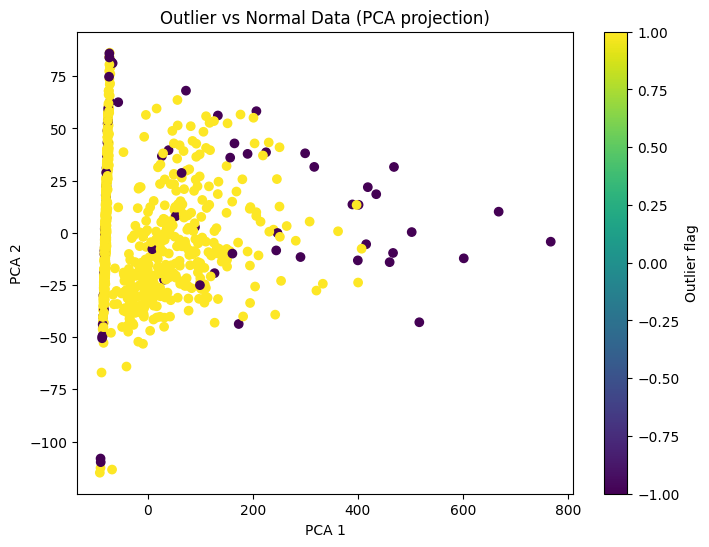

In [126]:
# ================================
# 🎯 PCA visualization of Outliers
# ================================
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df.drop(columns=["Outcome", "outlier"]))
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df["outlier"], cmap="viridis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Outlier vs Normal Data (PCA projection)")
plt.colorbar(label="Outlier flag")
plt.show()

In [127]:
# ================================
# 🧹 Replace zeros with NaN for selected columns (before scaling)
# ================================
cols_with_invalid_zero = [
    col for col in df.columns
    if col not in ["Pregnancies", "DiabetesPedigreeFunction", "Outcome", "outlier"]
]

for col in cols_with_invalid_zero:
    df[col] = df[col].replace(0, np.nan)

In [128]:
# 🔄 Missing value imputation (KNN)
features = df.drop(columns=["Outcome", "outlier"])
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(features)

df_imputed = pd.DataFrame(X_imputed, columns=features.columns, index=df.index)
df_imputed["Outcome"] = df["Outcome"]

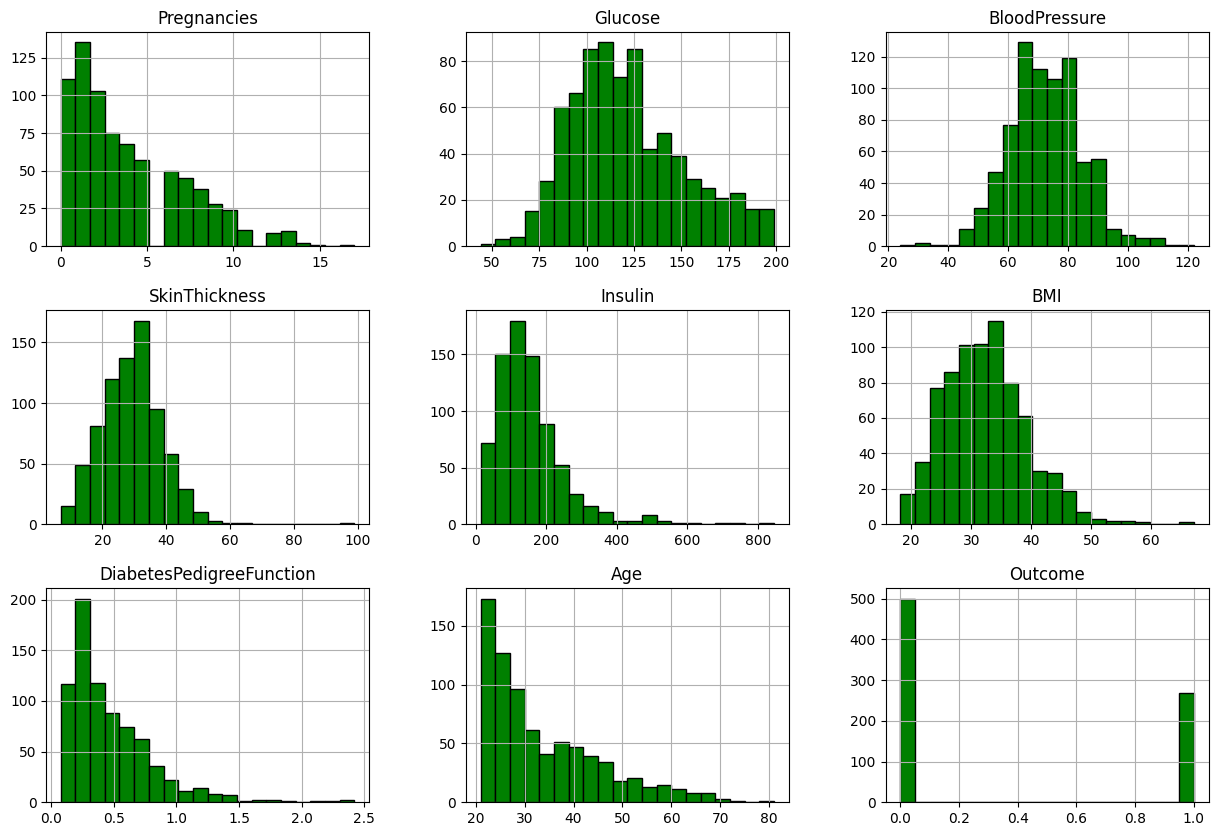

In [129]:
# ================================
# 📊 Histograms after imputation
# ================================
df_imputed.hist(bins=20, figsize=(15, 10), color="green", edgecolor="black")
plt.show()

In [130]:
# 📏 Standard Scaling (after imputation)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed.drop(columns="Outcome"))

df_scaled = pd.DataFrame(X_scaled, columns=features.columns, index=df.index)
df_scaled["Outcome"] = df_imputed["Outcome"]

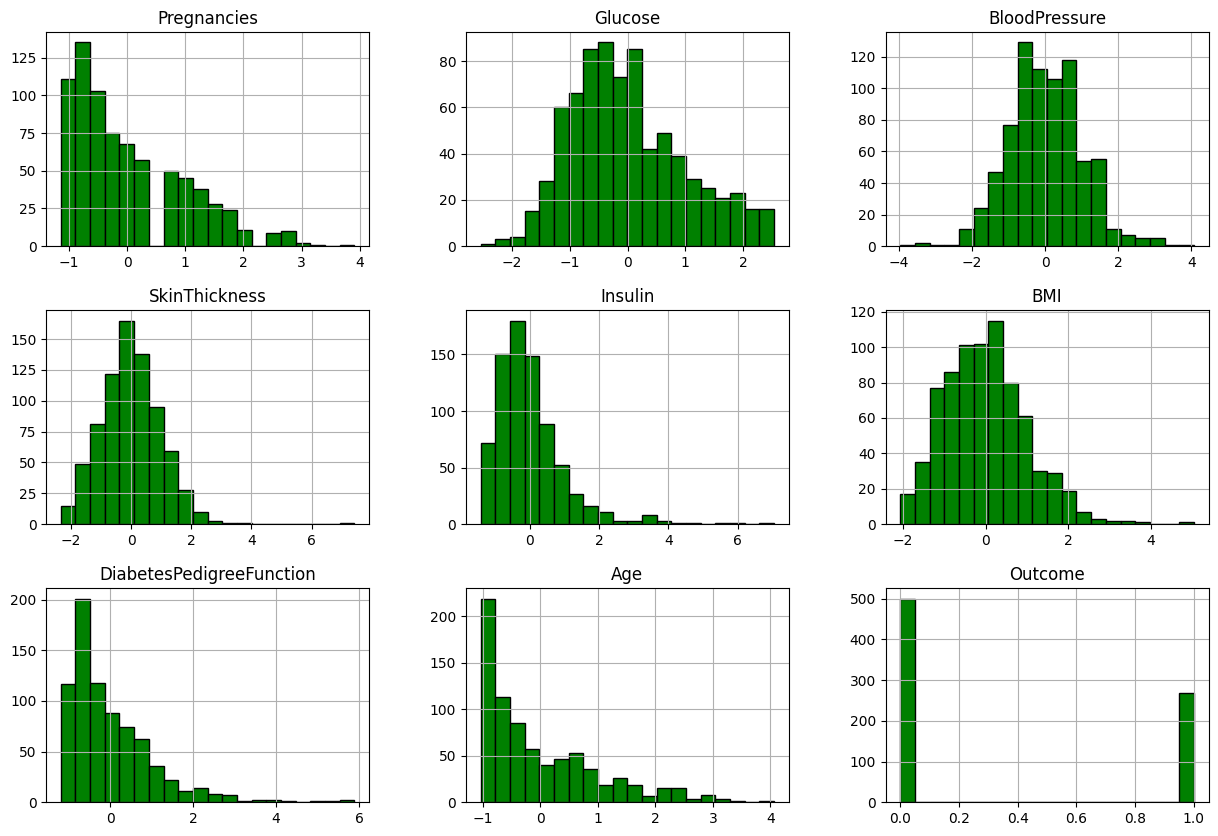

In [131]:
# ================================
# 📊 Histograms after imputation
# ================================
df_scaled.hist(bins=20, figsize=(15, 10), color="green", edgecolor="black")
plt.show()

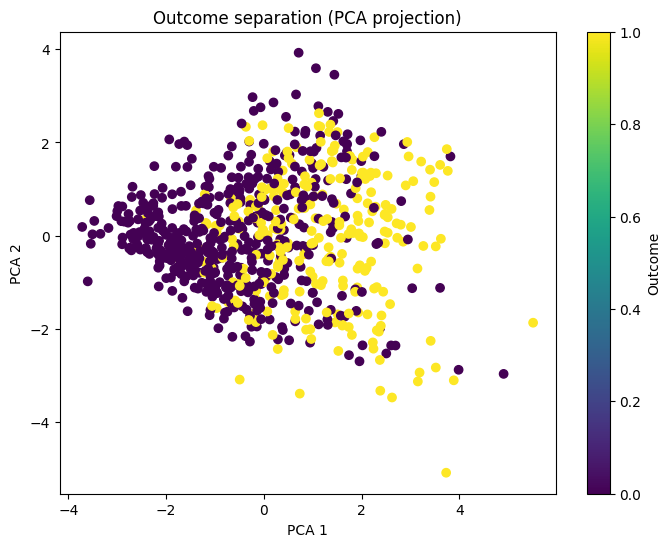

In [132]:
# 🎯 PCA visualization of Outcome
pca_data = pca.fit_transform(df_scaled.drop(columns="Outcome"))
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df_scaled["Outcome"], cmap="viridis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Outcome separation (PCA projection)")
plt.colorbar(label="Outcome")
plt.show()

In [ ]:
# 🚨 Final Outlier detection after imputation & scaling
iso_final = IsolationForest(contamination=0.1, random_state=42)
df_scaled["outlier"] = iso_final.fit_predict(df_scaled.drop(columns="Outcome"))

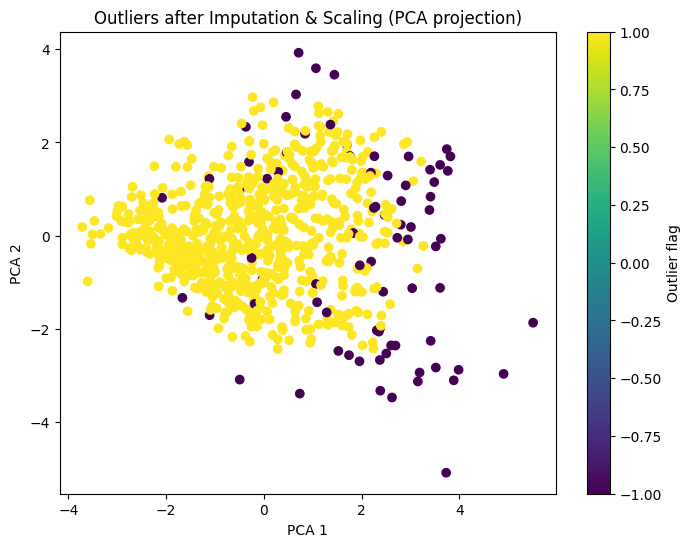

In [134]:
# PCA again
pca_data = pca.fit_transform(df_scaled.drop(columns=["Outcome", "outlier"]))
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=df_scaled["outlier"],
    cmap="viridis"
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Outliers after Imputation & Scaling (PCA projection)")
plt.colorbar(label="Outlier flag")
plt.show()

In [135]:
# 📊 Percentage of outliers removed in final step
outlier_count = (df_scaled["outlier"] == -1).sum()
total_count = len(df_scaled)
outlier_percentage = (outlier_count / total_count) * 100

print(f"🚨 Final Outliers detected: {outlier_count}")
print(f"📊 Total samples: {total_count}")
print(f"📉 Percentage removed: {outlier_percentage:.2f}%")

🚨 Final Outliers detected: 77
📊 Total samples: 768
📉 Percentage removed: 10.03%


In [136]:
print("✅ Data processing finished successfully!")

✅ Data processing finished successfully!


In [137]:
df_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,outlier
0,0.639947,0.866296,-0.031424,0.626067,0.162289,0.170762,0.468492,1.425995,1,1
1,-0.844885,-1.200858,-0.523271,-0.011089,-0.961861,-0.846475,-0.365061,-0.190672,0,1
2,1.233880,2.014715,-0.687220,-0.350906,0.117486,-1.326030,0.604397,-0.105584,1,1
3,-0.844885,-1.069610,-0.523271,-0.648246,-0.601400,-0.628496,-0.920763,-1.041549,0,1
4,-1.141852,0.505364,-2.654609,0.626067,0.152107,1.551298,5.484909,-0.020496,1,-1


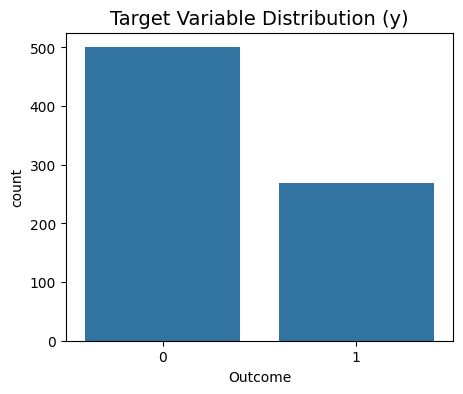

In [138]:
# 1️⃣ plot by y
plt.figure(figsize=(5,4))
sns.countplot(data=df_scaled, x='Outcome')
plt.title('Target Variable Distribution (y)', fontsize=14)
plt.show()

no smot need!

In [139]:
from sklearn.model_selection import train_test_split 
df_scaled=df_scaled.drop("outlier" , axis=1)
x=df_scaled.drop(["Outcome"], axis=1)
y=df_scaled["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
X_train.shape

(614, 8)

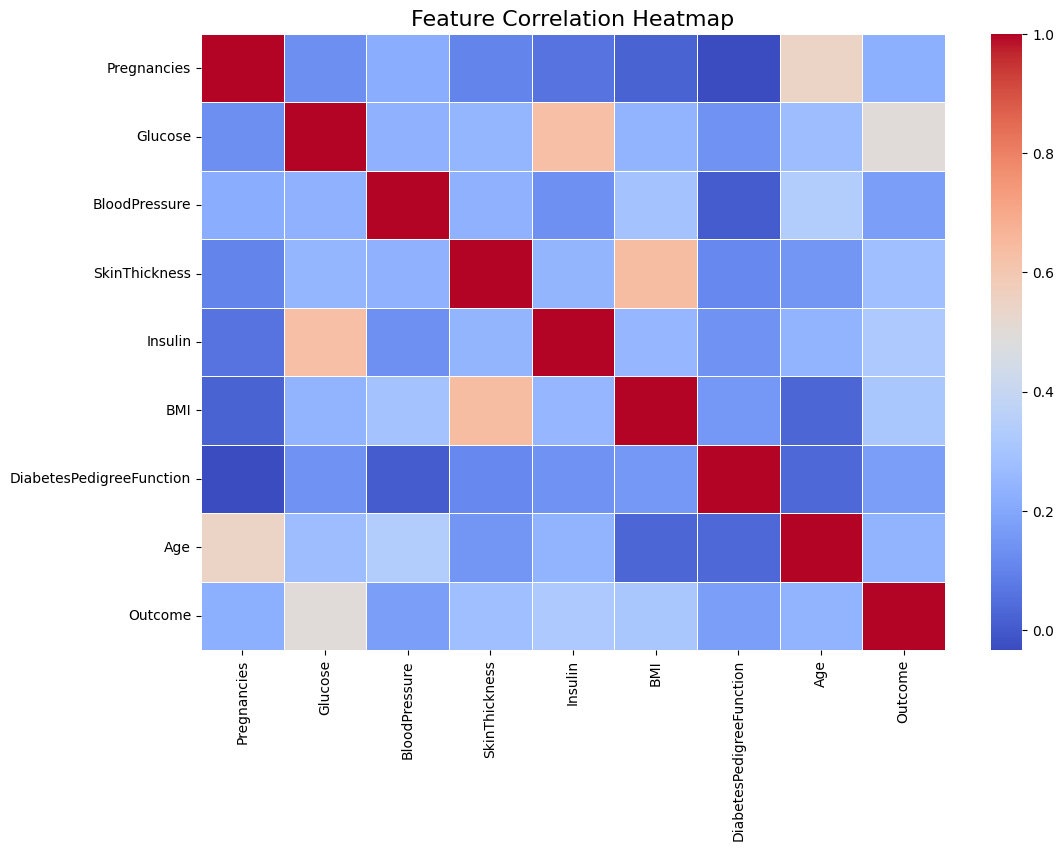

In [140]:
# 3️⃣ Feature Correlation Matrix
plt.figure(figsize=(12,8))
corr_matrix = df_scaled.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

In [141]:
# i find that Glucose is more important and related to Outcome ! 
# let's see it in another way 

                    Feature  Importance
1                   Glucose    0.222046
4                   Insulin    0.165530
5                       BMI    0.143152
7                       Age    0.124682
3             SkinThickness    0.104139
6  DiabetesPedigreeFunction    0.102399
2             BloodPressure    0.073036
0               Pregnancies    0.065017


C:\Users\p-fr\AppData\Local\Temp\ipykernel_11248\1411881517.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importances, x='Importance', y='Feature', palette='viridis')


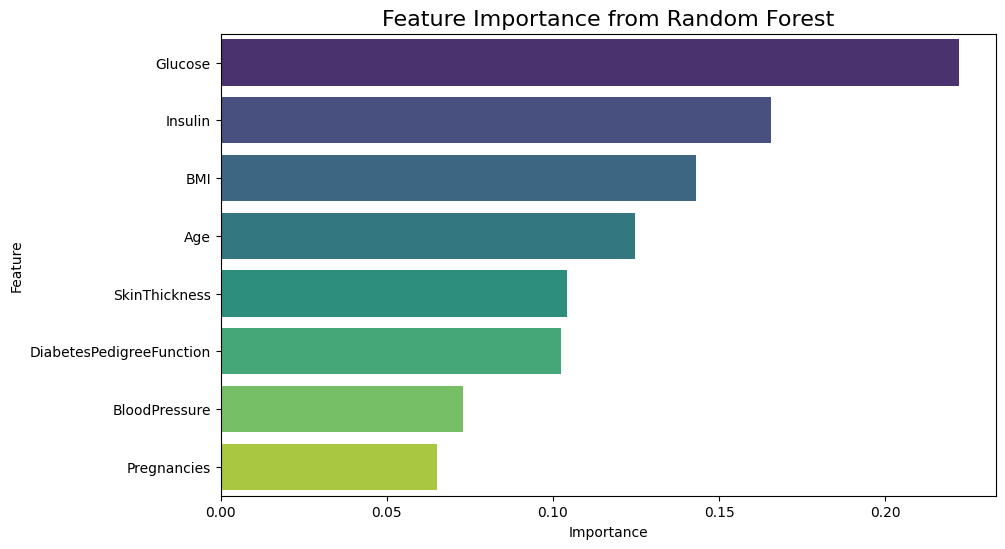

In [142]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RandomForest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# importance :
importances = rf_model.feature_importances_

# make DataFrame 
feat_importances = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


print(feat_importances)

# plot
plt.figure(figsize=(10,6))
sns.barplot(data=feat_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance from Random Forest', fontsize=16)
plt.show()


so Glucose is really the most important 

___


---

# PART 2

---

---

use GreadseachCV with 3 model to see it in classic machin learning !

In [143]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

from scipy import stats

from xgboost import XGBClassifier

In [144]:
models_params = {
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}
    ),
    "XGBoost": (
        XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
        {"n_estimators": [100, 200], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]}
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42),
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1]}
    )
}

In [145]:
results = []
for model_name, (model, params) in models_params.items():
    print(f"🔍 Tuning {model_name} ...")
    grid = GridSearchCV(model, params, cv=3, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({
        "Model": model_name,
        "Best Params": grid.best_params_,
        "Test Accuracy": acc
    })

🔍 Tuning RandomForest ...
🔍 Tuning XGBoost ...
🔍 Tuning GradientBoosting ...


              Model                                        Best Params  \
2  GradientBoosting       {'learning_rate': 0.05, 'n_estimators': 100}   
0      RandomForest             {'max_depth': 10, 'n_estimators': 200}   
1           XGBoost  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...   

   Test Accuracy  
2       0.772727  
0       0.759740  
1       0.727273  


C:\Users\p-fr\AppData\Local\Temp\ipykernel_11248\2327381735.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Test Accuracy", y="Model", palette="viridis")


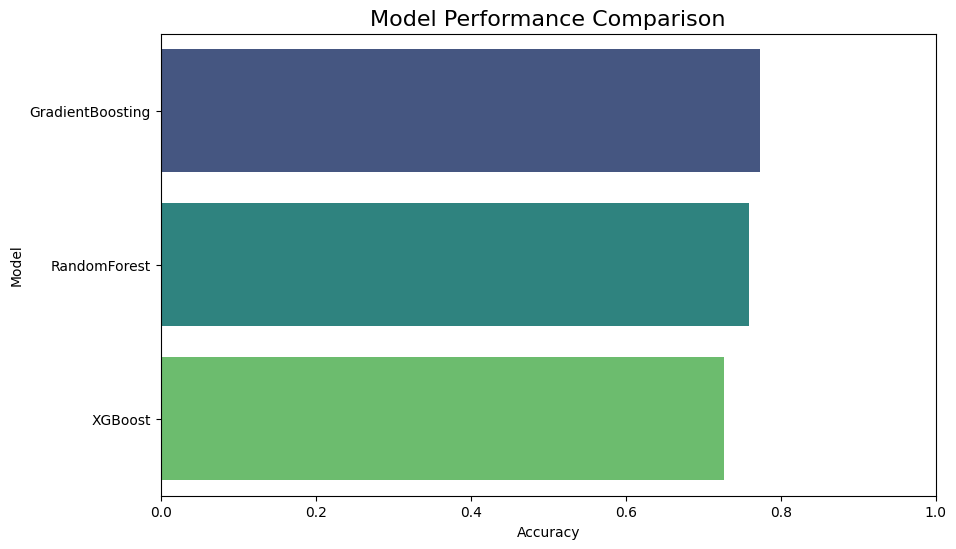

In [146]:
# ------------------------
# 7. Results & Plot
# ------------------------
results_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False)
print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Test Accuracy", y="Model", palette="viridis")
plt.title("Model Performance Comparison", fontsize=16)
plt.xlabel("Accuracy")
plt.xlim(0, 1)
plt.show()

the acc is not ok so use ann to improve it 

---

---


# PART 3 : ANN

---

---

In [147]:

from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_custom_nn(input_dim, layers_config, dropout_rate=0.5, activation='relu', output_units=3, output_activation='sigmoid'):
    """
    Build a neural network model with given configuration.

    Parameters:
        input_dim (int): Number of features
        layers_config (list): List of neurons per hidden layer
        dropout_rate (float): Dropout rate between layers
        activation (str): Hidden layer activation function
        output_units (int): Output neurons
        output_activation (str): Output activation (sigmoid for binary)
    """
    model = Sequential()

    # First layer with input dimension
    model.add(Dense(layers_config[0], activation=activation, input_dim=input_dim))
    model.add(Dropout(dropout_rate))

    # Additional hidden layers with dropout
    for units in layers_config[1:]:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(output_units, activation=output_activation))

    # Compile model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    return model


# <mark>test 1</mark>

c:\Users\p-fr\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.2872 - loss: 1.4112 - val_accuracy: 0.4390 - val_loss: 1.0914
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4216 - loss: 1.1991 - val_accuracy: 0.5772 - val_loss: 1.0720
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4501 - loss: 1.1909 - val_accuracy: 0.6667 - val_loss: 1.0648
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4969 - loss: 1.0864 - val_accuracy: 0.6098 - val_loss: 1.0539
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5356 - loss: 1.0640 - val_accuracy: 0.6016 - val_loss: 1.0396
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5967 - loss: 1.0127 - val_accuracy: 0.6098 - val_loss: 1.0220
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6212 - loss: 0.9898 - val_accuracy: 0.6098 - val_loss: 1.0018
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6008 - loss: 0.9799 - val_accuracy: 0.6098 - v

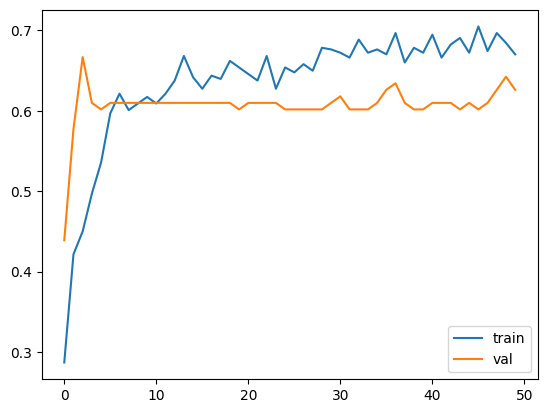

In [148]:

from tensorflow.keras.callbacks import ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Build model with specific layer sizes
model = build_custom_nn(input_dim=X_train.shape[1], layers_config=[64,32,16,8], dropout_rate=0.5)

# Train model with validation split
history = model.fit(X_train, y_train, epochs=50, callbacks=[early_stop], verbose=1, validation_split=0.2)

# Plot training/validation accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

In [149]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6688 - loss: 0.5637
Test Accuracy: 0.6688


### test 1 result: NO

# <mark>test 2:</mark>

c:\Users\p-fr\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6457 - loss: 0.9773 - val_accuracy: 0.6486 - val_loss: 0.8058
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6457 - loss: 0.7916 - val_accuracy: 0.6486 - val_loss: 0.6935
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6620 - loss: 0.7167 - val_accuracy: 0.6973 - val_loss: 0.6423
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6737 - loss: 0.6651 - val_accuracy: 0.7297 - val_loss: 0.5975
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7319 - loss: 0.6211 - val_accuracy: 0.7514 - val_loss: 0.5467
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7133 - loss: 0.6106 - val_accuracy: 0.7514 - val_loss: 0.5121
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7273 - loss: 0.5766 - val_accuracy: 0.7514 - val_loss: 0.5012
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7273 - loss: 0.5584 - val_accuracy: 0.7676 - v

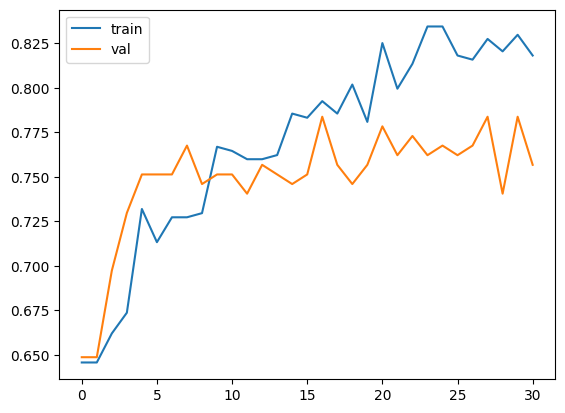

In [150]:
model = build_custom_nn(input_dim=X_train.shape[1], layers_config=[256,128,64,32,16,8], dropout_rate=0.1)

# Train model with validation split
history = model.fit(X_train, y_train, epochs=50, callbacks=[early_stop], verbose=1, validation_split=0.3)

# Plot training/validation accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

In [151]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7208 - loss: 0.5779
Test Accuracy: 0.7208


# <mark> test 3</mark>

c:\Users\p-fr\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6599 - loss: 0.8851 - val_accuracy: 0.6829 - val_loss: 0.6269
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7189 - loss: 0.5864 - val_accuracy: 0.7642 - val_loss: 0.4887
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7434 - loss: 0.5527 - val_accuracy: 0.7561 - val_loss: 0.4971
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7597 - loss: 0.5424 - val_accuracy: 0.7642 - val_loss: 0.4718
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7923 - loss: 0.5002 - val_accuracy: 0.7480 - val_loss: 0.4642
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7862 - loss: 0.4797 - val_accuracy: 0.7642 - val_loss: 0.4627
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7678 - loss: 0.4865 - val_accuracy: 0.7642 - val_loss: 0.4563
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8004 - loss: 0.4472 - val_accuracy: 0.

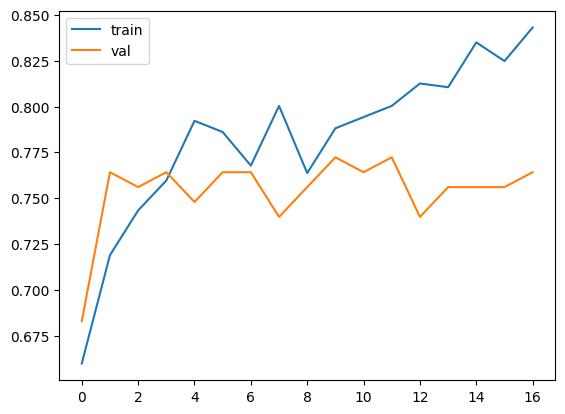

In [152]:
model = build_custom_nn(input_dim=X_train.shape[1], layers_config=[512,256,128,64,32,16,8], dropout_rate=0.05)

# Train model with validation split
history = model.fit(X_train, y_train, epochs=100, callbacks=[early_stop], validation_split=0.2)

# Plot training/validation accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

In [153]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7208 - loss: 0.5661
Test Accuracy: 0.7208


---
----
# part 4 :SVM
----
---

In [154]:
from sklearn import svm
clf = svm.SVC(kernel='rbf')
clf.fit(X_train, y_train) 

SVC()

In [155]:
yhat = clf.predict(X_test)

In [156]:
from sklearn.metrics import f1_score
f1_score(y_test, yhat, average='weighted')

0.7483614805145359

In [158]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, yhat)

np.float64(0.45714285714285713)

In [159]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[81 18]
 [17 38]]


---
---
# part 5 :BEST model 
---
---

In [160]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score


gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=100,
    random_state=42
)


gb_model.fit(X_train, y_train)


y_pred = gb_model.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")


Accuracy: 77.27%


## best model is GradientBoostingClassifier